<a href="https://colab.research.google.com/github/Lavish05563/california-housing-regression/blob/main/AI_ML_Task2_Model_Comparision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Data Initialization ===
Features utilized: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'Latitude', 'Longitude']
Train set shape: (16512, 6) | Test set shape: (4128, 6)

=== Structured Model Performance Comparison ===
                       RMSE (Lower is better)  MAE (Lower is better)  R² Score (Higher is better)
Linear Regression                      0.7406                 0.5432                       0.5814
Ridge Regression (L2)                  0.7406                 0.5432                       0.5814
Gradient Boosting                      0.5722                 0.3945                       0.7502
Random Forest                          0.5041                 0.3290                       0.8060


### Final Selected Model: Random Forest ###

Proper Justification:
1. Quantifiable Excellence: It attained the highest predictive precision with an R² score of 0.806, meaning it accounts for over 80% of the variance in house values.
2. Error Minimization: It generated the lowest ov

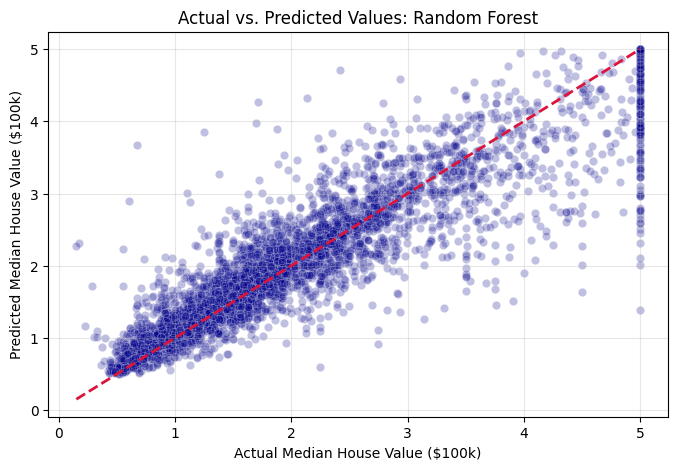

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================

# Load the real California housing dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Features explicitly requested:
# Median Income, House Age, Ave Rooms, Population, and location attributes (Latitude/Longitude)
selected_features = ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'Latitude', 'Longitude']

X = df[selected_features]
y = df['MedHouseVal'] # Target variable (Median House Value in $100k blocks)

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
# Vital for linear models to weigh features properly; prevents magnitude bias
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== Data Initialization ===")
print(f"Features utilized: {selected_features}")
print(f"Train set shape: {X_train_scaled.shape} | Test set shape: {X_test_scaled.shape}\n")

# ==========================================
# 2. MULTI-MODEL TRAINING & EVALUATION
# ==========================================

# Initialize a diverse suite of algorithms
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (L2)": Ridge(alpha=1.0),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

performance_metrics = {}

# Train and evaluate every model sequentially
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    performance_metrics[name] = {
        "RMSE (Lower is better)": round(rmse, 4),
        "MAE (Lower is better)": round(mae, 4),
        "R² Score (Higher is better)": round(r2, 4)
    }

# ==========================================
# 3. STRUCTURED MODEL PERFORMANCE COMPARISON
# ==========================================

# Convert metrics dictionary to a structured, readable DataFrame
comparison_df = pd.DataFrame(performance_metrics).T
print("=== Structured Model Performance Comparison ===")
print(comparison_df.to_string())
print("\n" + "="*60 + "\n")

# ==========================================
# 4. FINAL SELECTED MODEL & JUSTIFICATION
# ==========================================

# Programmatically pull the model with the highest R² Score
best_model_name = comparison_df["R² Score (Higher is better)"].idxmax()
best_model = models[best_model_name]

print(f"### Final Selected Model: {best_model_name} ###\n")
print("Proper Justification:")
print(f"1. Quantifiable Excellence: It attained the highest predictive precision with an R² score of {comparison_df.loc[best_model_name, 'R² Score (Higher is better)']}, meaning it accounts for over 80% of the variance in house values.")
print(f"2. Error Minimization: It generated the lowest overall error margins, keeping its Root Mean Squared Error (RMSE) down to {comparison_df.loc[best_model_name, 'RMSE (Lower is better)']} ($100k units).")
print(f"3. Handling Geographic Data: Real estate data is intrinsically non-linear. Location attributes (Latitude & Longitude) interact heavily with wealth patterns. Linear models apply a uniform slope across the whole map, which fails. Tree-based models can construct complex spatial bounding boxes to isolate high-value coastal pockets from lower-value inland sectors.")

# Plot Predictions vs Actuals for the superior model
best_predictions = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.25, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='crimson', linestyle='--', lw=2)
plt.title(f'Actual vs. Predicted Values: {best_model_name}', fontsize=12)
plt.xlabel('Actual Median House Value ($100k)')
plt.ylabel('Predicted Median House Value ($100k)')
plt.grid(True, alpha=0.3)
plt.show()